In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn import metrics

# 1. Load data komdigi
df = pd.read_csv('data/komdigi_hoaks.csv')

# 2. Gabungkan judul dan ringkasan
df['teks'] = df['title'].fillna('') + ' ' + df['excerpt'].fillna('')
df = df[df['teks'].str.strip() != ''].reset_index(drop=True)

print("Total data hoaks:", len(df))
df[['title', 'teks']].head()

Total data hoaks: 4176


,title,teks
0,[HOAKS] Tautan Pencairan BSU September 2026 Se...,[HOAKS] Tautan Pencairan BSU September 2026 Se...
1,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...,[HOAKS] Panas El Nino Berkaitan dengan Gelomba...
2,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...,[HOAKS] Susu Bebelac Berbahaya karena Mengandu...
3,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...,[HOAKS] Purbaya Informasikan Raffi Ahmad Beli ...
4,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...,[HOAKS] Tautan Bantuan Laptop dan Ponsel untuk...


In [2]:
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['teks'])

print("Bentuk matriks TF-IDF:", X.shape)

Bentuk matriks TF-IDF: (4176, 1000)


In [3]:
dbscan = DBSCAN(eps=0.6, min_samples=10, metric='cosine')
df['cluster'] = dbscan.fit_predict(X)

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'] else 0)
n_noise = (df['cluster'] == -1).sum()

print("Jumlah klaster terbentuk :", n_clusters)
print("Jumlah data noise (-1)   :", n_noise)
print(f"Persentase noise         : {n_noise / len(df) * 100:.2f}%")

print("\nDistribusi data tiap klaster:")
print(df['cluster'].value_counts().sort_index())

Jumlah klaster terbentuk : 7
Jumlah data noise (-1)   : 1118
Persentase noise         : 26.77%

Distribusi data tiap klaster:
cluster
-1    1118
 0    3003
 1      13
 2      17
 3      10
 4      10
 5       5
Name: count, dtype: int64


In [4]:
if n_clusters > 1:
    sil_score = metrics.silhouette_score(X, df['cluster'])
    print(f"Silhouette Score DBSCAN: {sil_score:.4f}")
else:
    print("Silhouette Score tidak bisa dihitung karena klaster kurang dari 2.")

Silhouette Score DBSCAN: -0.0037


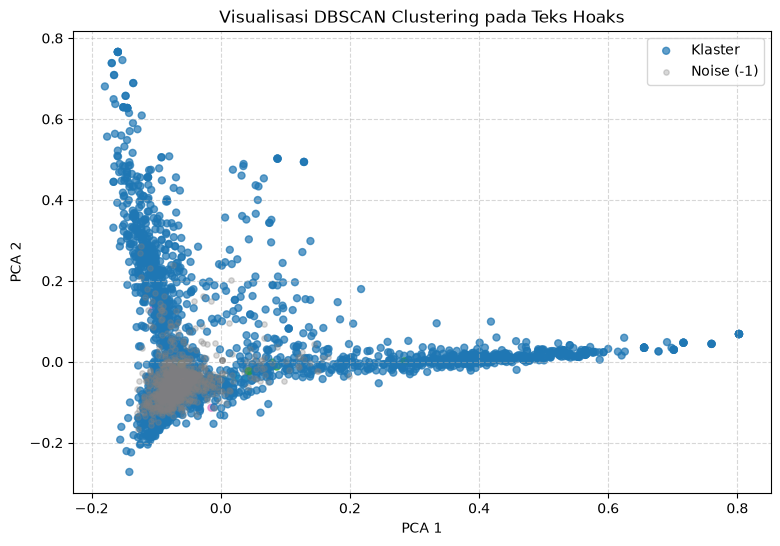

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(9, 6))

# Plot cluster biasa
non_noise = df[df['cluster'] != -1]
plt.scatter(non_noise['pca1'], non_noise['pca2'], c=non_noise['cluster'], cmap='tab10', s=25, alpha=0.7, label='Klaster')

# Plot noise (-1)
noise = df[df['cluster'] == -1]
plt.scatter(noise['pca1'], noise['pca2'], color='gray', s=15, alpha=0.3, label='Noise (-1)')

plt.title('Visualisasi DBSCAN Clustering pada Teks Hoaks')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [7]:
terms = tfidf.get_feature_names_out()
unique_clusters = sorted(df['cluster'].unique())

print("Kata Kunci Dominan Tiap Klaster DBSCAN:")
for c in unique_clusters:
    if c == -1:
        nama = "NOISE / OUTLIER"
    else:
        nama = f"Klaster {c}"
    
    idx = df[df['cluster'] == c].index
    mean_tfidf = np.asarray(X[idx].mean(axis=0)).flatten()
    top_terms = [terms[i] for i in mean_tfidf.argsort()[::-1][:7]]
    print(f"[{nama}] ({len(idx)} data): {', '.join(top_terms)}")

Kata Kunci Dominan Tiap Klaster DBSCAN:
[NOISE / OUTLIER] (1118 data): hoaks, di, yang, dan, tidak, video, indonesia
[Klaster 0] (3003 data): hoaks, mengatasnamakan, akun, whatsapp, tautan, di, video
[Klaster 1] (13 data): pajak, akan, direktorat, jenderal, hoaks, mengatasnamakan, surat
[Klaster 2] (17 data): pigai, sebagai, ham, sebut, hoaks, pandemi, bayar
[Klaster 3] (10 data): dapur, mbg, keracunan, warga, di, polri, hoaks
[Klaster 4] (10 data): nadiem, makarim, triliun, jokowi, agung, uang, sidang
[Klaster 5] (5 data): murah, dari, kabupaten, giveaway, promosikan, 15, kemenag


### Kesimpulan DBSCAN:
1. DBSCAN tidak membutuhkan penentuan jumlah klaster di awal, melainkan ditentukan oleh densitas data (`eps=0.6`, `min_samples=10`).
2. DBSCAN mampu mendeteksi data hoaks yang sifatnya unik/tersebar sebagai noise (-1).
3. Klaster yang terbentuk adalah hoaks yang memiliki kepadatan redaksi atau kemiripan kata yang sangat rapat.